In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\ganes\Downloads\customer_shopping_behavior.csv")

df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
#no of columns and rows
df.shape

(3900, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3863.0,3.750065,0.716983,2.5,3.10,3.8,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


In [17]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(0)

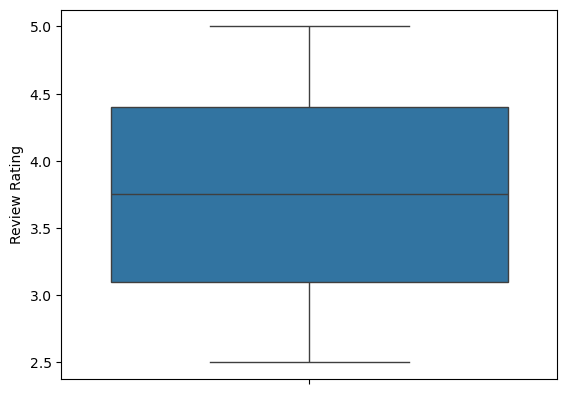

In [16]:
#Does this column contain outliers?
sns.boxplot(df["Review Rating"])
plt.show()

In [36]:
#cleaning
#df["Review Rating"]=df["Review Rating"].fillna(df["Review Rating"].median())
df["Review Rating"]=df["Review Rating"].fillna(df["Review Rating"].mean())


In [22]:
df=df.rename(columns={"Purchase Amount (USD)":"Purchase Amount"})
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

Exploratory Data Analysis (EDA)

Univariate Analysis

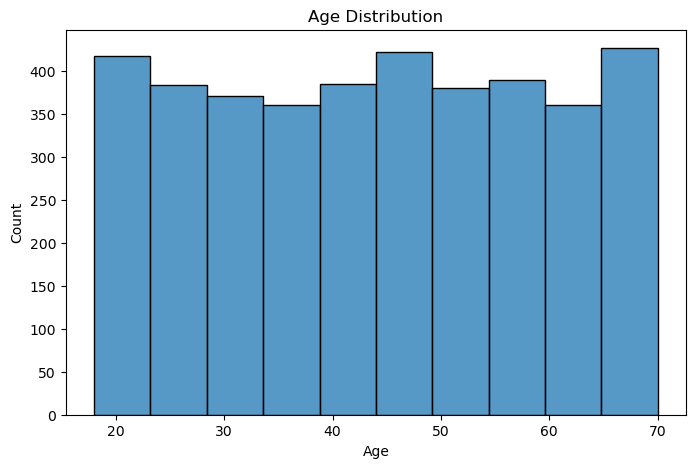

In [23]:
#Which age group appears more in our dataset?
plt.figure(figsize=(8,5))

sns.histplot(df["Age"],bins=10)

plt.title("Age Distribution")
plt.show()

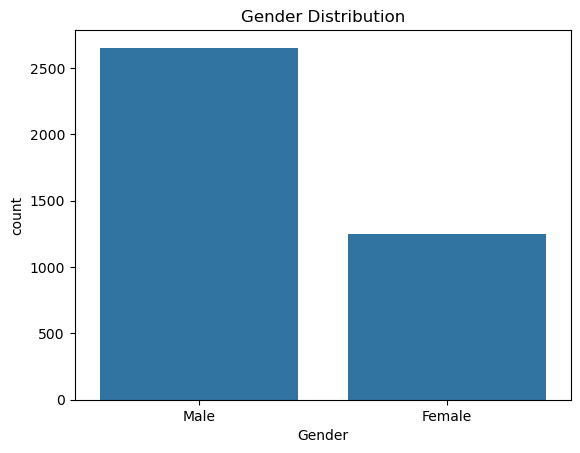

In [24]:
#How many male and female customers exist?
sns.countplot(x="Gender",data=df)

plt.title("Gender Distribution")

plt.show()

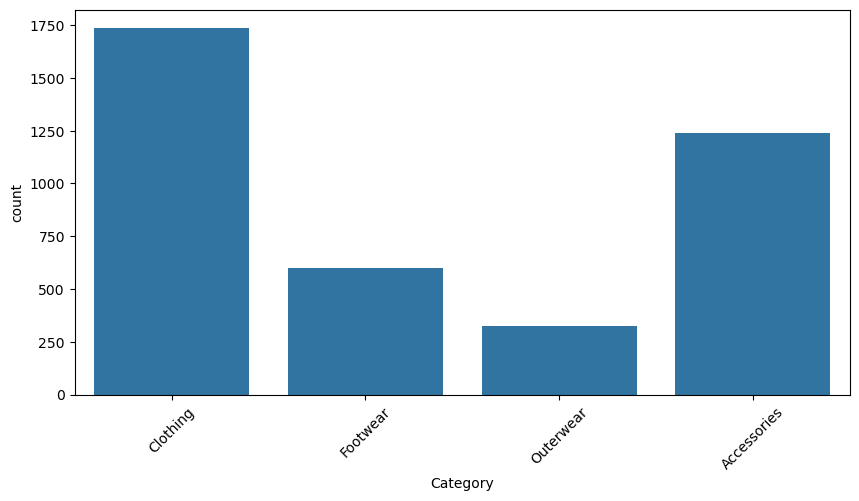

In [25]:
#Product Category Analysis-Which category is purchased more?
plt.figure(figsize=(10,5))

sns.countplot(
x="Category",
data=df
)

plt.xticks(rotation=45)

plt.show()

Bivariate Analysis

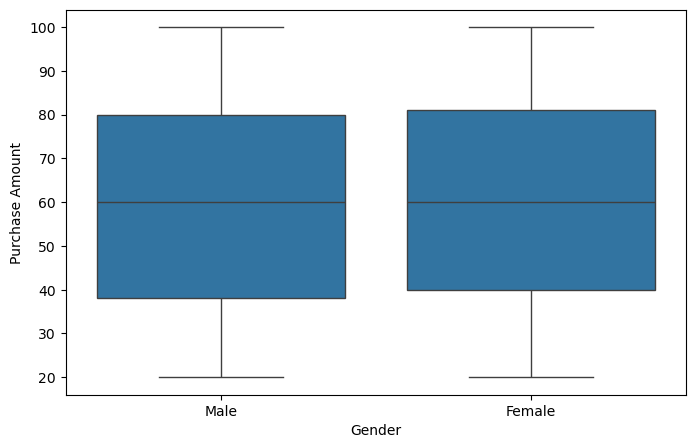

In [30]:
#Gender vs Pur-chase Amount-Which gender spends more?
plt.figure(figsize=(8,5))

sns.boxplot(
x="Gender",
y="Purchase Amount",
data=df
)

plt.show()

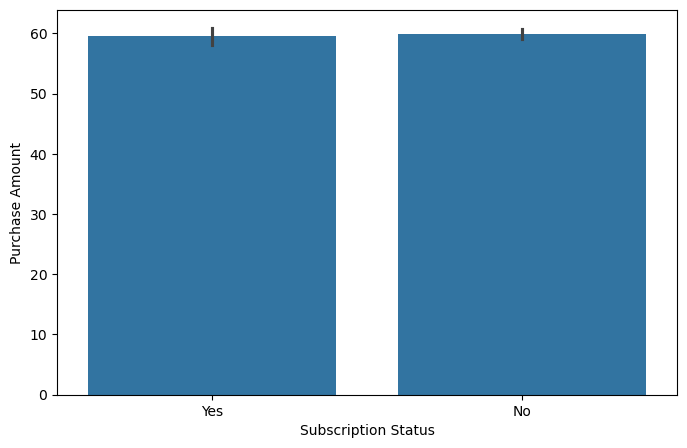

In [32]:
#Subscription Status vs Purchase Amount-Does subscription affect spending?
plt.figure(figsize=(8,5))

sns.barplot(
x="Subscription Status",
y="Purchase Amount",
data=df)
plt.show()

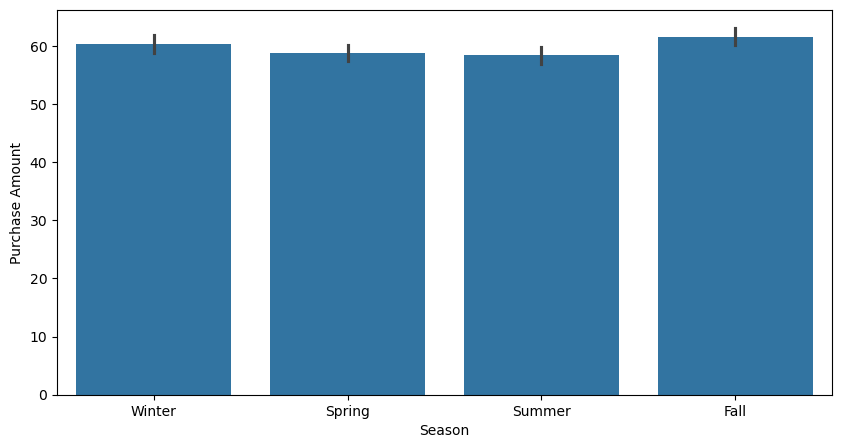

In [34]:
#Season vs Sales->Which season generates highest revenue?
plt.figure(figsize=(10,5))

sns.barplot(
x="Season",
y="Purchase Amount",
data=df
)

plt.show()

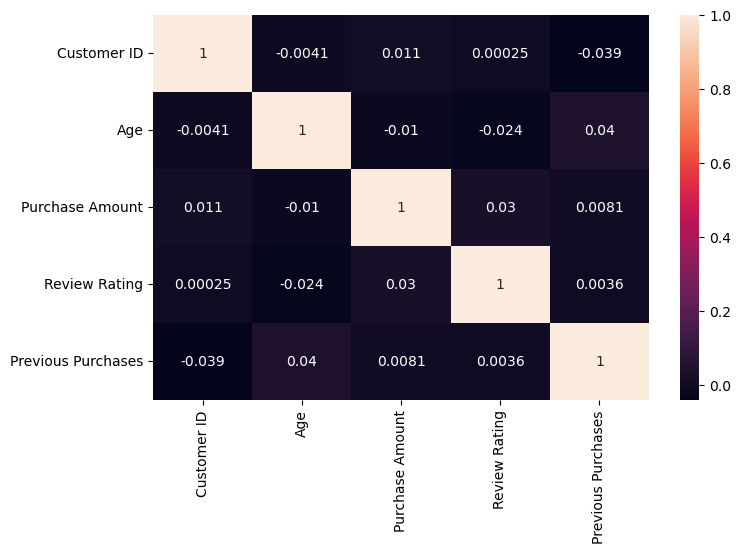

In [35]:
#Correlation Analysis->Which numerical variables influence each other?
numeric_df=df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,5))

sns.heatmap(
numeric_df.corr(),
annot=True)

plt.show()

Feature Engineering

In [40]:
#Creating new useful columns from existing columns
bins=[0,25,35,50,100]
labels=["Young","Adult","Middle Age","Senior"]
df["Age Group"]=pd.cut(df["Age"],bins=bins,labels=labels)
df[["Age","Age Group"]].head()

,Age,Age Group
0,55,Senior
1,19,Young
2,50,Middle Age
3,21,Young
4,45,Middle Age


In [43]:
#Spending Category->Let's classify customers by purchase amount
bins=[0,30,60,100]

labels=["Low Spender","Medium Spender","High Spender"]

df["Spending Category"]=pd.cut(
    df["Purchase Amount"], bins=bins,labels=labels
)
df[["Age","Age Group",
    "Purchase Amount","Spending Category"]].head()

,Age,Age Group,Purchase Amount,Spending Category
0,55,Senior,53,Medium Spender
1,19,Young,64,High Spender
2,50,Middle Age,73,High Spender
3,21,Young,90,High Spender
4,45,Middle Age,49,Medium Spender


In [51]:
checking both have same value or not if we have then we can drop one column
df[['Discount Applied','Promo Code Used']].head(10)

,Discount Applied,Promo Code Used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [53]:
(df['Discount Applied']==df["Promo Code Used"]).all()

np.True_

In [64]:
#drop Promo Code Used
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases', 'Age Group', 'Spending Category'],
      dtype='object')

KPI Analysis

In [66]:
total_customers=df["Customer ID"].nunique()
total_sales=df["Purchase Amount"].sum()
avg_purchase=df["Purchase Amount"].mean()
avg_rating=df["Review Rating"].mean()
subscribers=df[df["Subscription Status"]=="Yes"].shape[0]

print("Total Customers:",total_customers)
print("Total Sales:",total_sales)
print("Average Purchase:",avg_purchase)
print("Average Rating:",avg_rating)
print("Subscribers:",subscribers)

Total Customers: 3900
Total Sales: 233081
Average Purchase: 59.76435897435898
Average Rating: 3.750064716541548
Subscribers: 1053
